# Benign vs. attack — three maps per attack type (raw VeReMi)

For each of the four attack types, one run folder and one shared time window:

| Map | Shows | Source |
|---|---|---|
| **x · Benign** | a Benign-labeled vehicle's own true path | its own `traceJSON-*-A0-*.json`, type-2 records |
| **y · Attack** | what the network heard from one attacker | neighbors' received messages, type-3 records |
| **Both** | the two overlaid on one clock | — |

**What "attack" means per type** (verified on the raw data):
- **GridSybil** broadcasts ghosts under pseudonyms the ground-truth ledger never records, so the attack
  trace is one *fake pseudonym*.
- **DataReplay, DoSRandom, DoSDisruptive** rotate pseudonyms every 1–2 messages (all recorded in ground
  truth) while broadcasting positions far from the truth, so the attack trace is *every pseudonym heard from
  that vehicle*.

The benign and attack traces are **different vehicles** from the same run, clipped to the time they share.
Neither is derived from the other; "x" and "y" are display labels only. The simulator's "Benign vs attack"
mode shows the same pairs from its exported sample.

Read-only on `data/` (CLAUDE.md rule 2). Run from the repo root (rule 5). The extraction code is imported
from `scripts/export_simulation_sample.py`, not copied, so the notebook and the simulator pick attack
traces the same way. Each attack type scans one run folder once (tens of seconds each).


In [3]:
import json
import pathlib
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = pathlib.Path("..")
RAW = ROOT / "data" / "VeReMi-Dataset"
assert RAW.exists(), "run this notebook from the repo root (CLAUDE.md rule 5) -- data/VeReMi-Dataset not found"
sys.path.insert(0, str(ROOT / "scripts"))
import export_simulation_sample as exp  # noqa: E402  (reused: resolver, forger, per-family strategy)

FEATURES = ["pos_x", "pos_y", "spd_x", "spd_y", "acl_x", "acl_y", "hed_x", "hed_y",
            "dt", "dpos_x", "dpos_y", "dspd_x", "dspd_y"]
TRACE_NAME = re.compile(r"traceJSON-(\d+)-(\d+)-A(\d+)-(\d+)-(\d+)\.json")
GREEN, RED = "#16A34A", "#DC2626"  # the project's benign / attack colours (tracker.html, simulator)
SIGNATURES = {  # observed patterns, from docs/research-notes/data_understanding/attack-taxonomy.md
    "GridSybil": "Several ghost pseudonyms clustered around one point; position and claimed speed disagree.",
    "DataReplaySybil": "Stale positions re-broadcast (frozen or repeated) while other fields keep updating.",
    "DoSRandomSybil": "Incoherent position jumps at an elevated message rate.",
    "DoSDisruptiveSybil": "Mostly single-shot disposable pseudonyms with bursty, irregular timing.",
}


## 1. Configuration

`SUBFOLDERS[family] = None` takes the first run folder for that attack type. GridSybil in 0709 broadcasts
almost only the shared sentinel pseudonym `#1`, whose ghosts span kilometres, so the defaults use 1416 and
prefer a non-sentinel fake pseudonym. Every result prints the folder and pseudonym it used.


In [4]:
FAMILIES = ["GridSybil", "DataReplaySybil", "DoSRandomSybil", "DoSDisruptiveSybil"]
GROUP = "1416"
SUBFOLDERS = {family: None for family in FAMILIES}   # e.g. {"DoSRandomSybil": "VeReMi_50400_54000_..."}
MAX_ATTACKERS_TO_SCAN = 40     # bounds the one raw-file pass per run
MIN_STEPS = 20                 # at least one model window (20 steps) on each side
PREFER_NON_SENTINEL = True     # GridSybil only: avoid the shared sentinel pseudonym #1 when possible


## 2. The pipeline, as functions

`build_pair(family)` indexes one run, picks an attacker's broadcast trace with the family's strategy, finds
the benign vehicle overlapping it longest, and clips both to the overlap. `show(pair)` draws the three maps
and the speed plot.


In [5]:
def read_own_track(path):
    """A vehicle's own true positions: the type-2 records in its own trace file."""
    times, pos, spd = [], [], []
    with open(path, encoding="utf-8") as fh:
        for line in fh:
            if '"type":2' not in line:
                continue
            rec = json.loads(line)
            times.append(rec["rcvTime"])
            pos.append(rec["pos"][:2])
            spd.append(rec["spd"][:2])
    order = np.argsort(times)
    return np.asarray(times)[order], np.asarray(pos)[order], np.asarray(spd)[order]


def build_pair(family, group=GROUP, subfolder=None):
    family_dir = RAW / f"{family}_{group}"
    subfolder = subfolder or sorted(p.name for p in family_dir.iterdir() if p.is_dir())[0]
    run_dir = family_dir / subfolder
    folder = f"{family}_{group}/{subfolder}"

    vehicles = []
    for path in sorted(run_dir.glob("traceJSON-*.json")):
        m = TRACE_NAME.match(path.name)
        if m:
            vehicles.append({"node": int(m.group(1)), "code": int(m.group(3)), "path": path})
    benign_files = [v for v in vehicles if v["code"] == 0]
    attacker_nodes = sorted({v["node"] for v in vehicles if v["code"] != 0})

    # y: attack trace, with the same per-family strategy the simulator's exporter uses.
    resolver = exp.PseudonymResolver(RAW, ROOT / "simulation" / ".cache" / "pseudonym_map.json")  # gitignored
    resolver.load_or_build([(family, group, subfolder)])
    targets = set(attacker_nodes[:MAX_ATTACKERS_TO_SCAN])
    scanned = exp.BroadcastForger(RAW).scan(family, group, subfolder, targets)
    found = []
    for node in sorted(targets):
        hit = exp.BroadcastForger.pick_attack_trace(
            scanned, node, family, resolver.pseudonyms_of(family, group, subfolder, node), min_steps=MIN_STEPS)
        if hit:
            found.append((node, *hit))   # (node, strategy, pseudonym, rows, n_pseudonyms)
    if not found:
        return {"family": family, "folder": folder, "ok": False, "why": "no attack trace with enough messages"}
    found.sort(key=lambda f: ((PREFER_NON_SENTINEL and f[1] == "fake_pseudonym" and f[2] == 1), -len(f[3])))
    attack_node, strategy, pseudo, rows, n_pseudo = found[0]
    steps, times = exp._rows_to_forged_trajectory(rows, FEATURES)

    # x: the benign vehicle overlapping that trace longest, >= MIN_STEPS on both sides.
    a0, a1 = times[0], times[-1]
    best = None
    for v in benign_files:
        t, p, s = read_own_track(v["path"])
        if len(t) == 0:
            continue
        lo, hi = max(t[0], a0), min(t[-1], a1)
        n_b = np.count_nonzero((t >= lo) & (t <= hi))
        n_a = np.count_nonzero((times >= lo) & (times <= hi))
        if hi > lo and n_b >= MIN_STEPS and n_a >= MIN_STEPS and (best is None or hi - lo > best["hi"] - best["lo"]):
            best = {"node": v["node"], "t": t, "pos": p, "spd": s, "lo": lo, "hi": hi}
    if best is None:
        return {"family": family, "folder": folder, "ok": False, "why": "no benign vehicle overlaps long enough"}

    lo, hi = best["lo"], best["hi"]
    b = (best["t"] >= lo) & (best["t"] <= hi)
    a = (times >= lo) & (times <= hi)
    col = FEATURES.index
    dt = steps[a][:, col("dt")]
    with np.errstate(divide="ignore", invalid="ignore"):
        implied = np.where(dt > 0, np.hypot(steps[a][:, col("dpos_x")], steps[a][:, col("dpos_y")]) / dt, np.nan)
    return {
        "family": family, "folder": folder, "ok": True, "lo": lo, "hi": hi,
        "benign_node": best["node"], "benign_xy": best["pos"][b], "benign_t": best["t"][b], "benign_spd": best["spd"][b],
        "attack_node": attack_node, "strategy": strategy, "pseudonym": pseudo, "n_pseudonyms": n_pseudo,
        "attack_xy": steps[a][:, [col("pos_x"), col("pos_y")]], "attack_t": times[a],
        "attack_spd": steps[a][:, [col("spd_x"), col("spd_y")]], "attack_implied": implied,
        "attackers_with_trace": len(found),
    }


def trace_label(pair):
    return (f"fake pseudonym #{pair['pseudonym']}" if pair["strategy"] == "fake_pseudonym"
            else f"{pair['n_pseudonyms']} pseudonyms")


def show(pair):
    family = pair["family"]
    print(f"{family}: {SIGNATURES[family]}")
    print(f"folder: {pair['folder']}")
    if not pair["ok"]:
        print("skipped:", pair["why"])
        return
    print(f"benign vehicle {pair['benign_node']} vs attacker {pair['attack_node']} ({trace_label(pair)}), "
          f"shared window {pair['hi'] - pair['lo']:.0f} s")

    bxy, axy = pair["benign_xy"], pair["attack_xy"]
    both = np.vstack([bxy, axy])
    pad = 0.06 * max(np.ptp(both[:, 0]), np.ptp(both[:, 1]), 50.0)
    xlim = (both[:, 0].min() - pad, both[:, 0].max() + pad)
    ylim = (both[:, 1].min() - pad, both[:, 1].max() + pad)

    def draw(ax, xy, colour, label, as_points):
        # attack traces jump between positions, so they are points plus a faint line, not a solid path
        ax.plot(xy[:, 0], xy[:, 1], "-", color=colour, lw=0.8 if as_points else 1.8, alpha=0.35 if as_points else 1.0)
        if as_points:
            ax.plot(xy[:, 0], xy[:, 1], ".", color=colour, ms=4)
        ax.plot([], [], "-", color=colour, label=label)
        ax.plot(*xy[0], "o", color=colour, ms=7)
        ax.plot(*xy[-1], "x", color=colour, ms=9, mew=2)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
    panels = [
        (axes[0], [(bxy, GREEN, f"benign vehicle {pair['benign_node']}", False)], "x · Benign vehicle"),
        (axes[1], [(axy, RED, f"vehicle {pair['attack_node']}, {trace_label(pair)}", True)], f"y · {family} attack"),
        (axes[2], [(bxy, GREEN, "benign", False), (axy, RED, family, True)], "Both, same window"),
    ]
    for ax, traces, title in panels:
        for xy, colour, label, as_points in traces:
            draw(ax, xy, colour, label, as_points)
        ax.set_title(title)
        ax.set_xlabel("x (m)")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.3)
        ax.legend(loc="best", fontsize=8)
    axes[0].set_ylabel("y (m)")
    fig.suptitle(f"{family} vs Benign · {pair['folder']} · {pair['hi'] - pair['lo']:.0f} s   (circle = start, cross = end)", fontsize=11)
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 3.4))
    ax.plot(pair["benign_t"] - pair["lo"], np.hypot(*pair["benign_spd"].T), color=GREEN, lw=1.6, label="benign · claimed speed")
    ax.plot(pair["attack_t"] - pair["lo"], np.hypot(*pair["attack_spd"].T), color=RED, lw=1.4, label=f"{family} · claimed speed")
    ax.plot(pair["attack_t"] - pair["lo"], pair["attack_implied"], color=RED, lw=0.9, ls="--", alpha=0.7,
            label=f"{family} · implied speed (Δpos/Δt)")
    ax.set_yscale("symlog", linthresh=10)   # linear below 10 m/s, log above: normal speeds and jumps both visible
    ax.set_xlabel("seconds into the shared window")
    ax.set_ylabel("m/s (symlog)")
    ax.set_title(f"{family} vs Benign · speed · {pair['folder']}", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


pairs = {}


## 3. GridSybil (A16) vs Benign

*Several ghost pseudonyms clustered around one point; position and claimed speed disagree.*


GridSybil: Several ghost pseudonyms clustered around one point; position and claimed speed disagree.
folder: GridSybil_1416/VeReMi_50400_54000_2022-9-11_19:13:55
benign vehicle 117 vs attacker 111 (fake pseudonym #201115), shared window 182 s


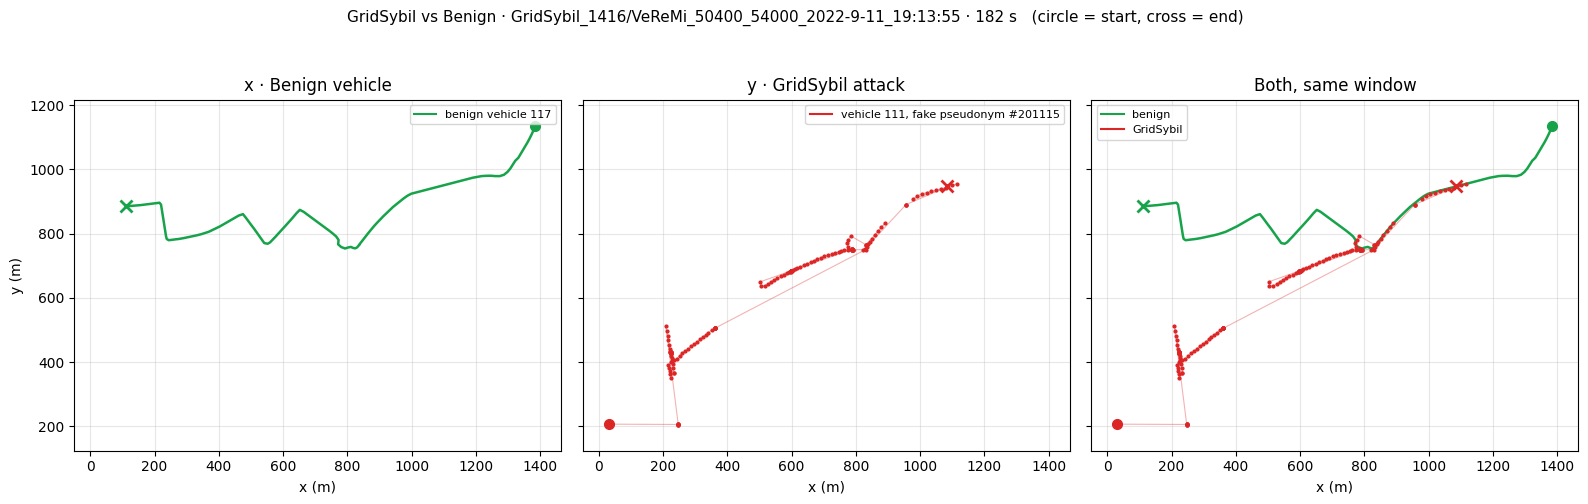

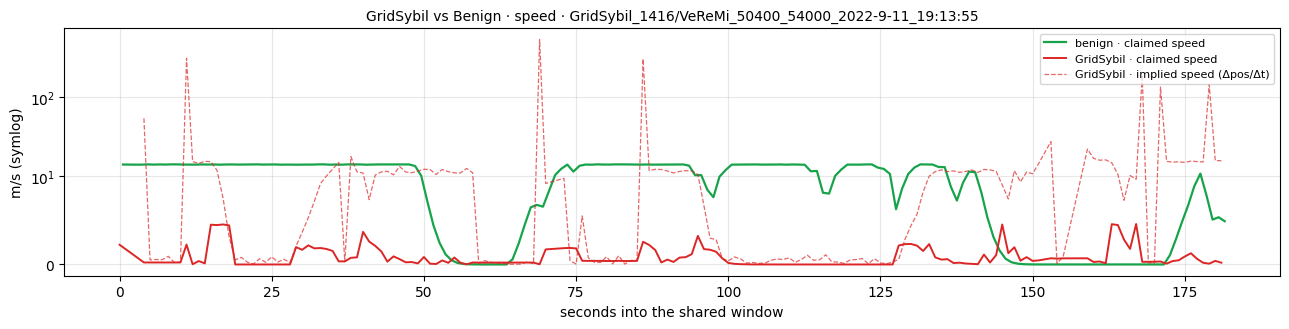

In [6]:
pairs["GridSybil"] = build_pair("GridSybil", subfolder=SUBFOLDERS["GridSybil"])
show(pairs["GridSybil"])


## 4. DataReplaySybil (A17) vs Benign

*Stale positions re-broadcast (frozen or repeated) while other fields keep updating.*


DataReplaySybil: Stale positions re-broadcast (frozen or repeated) while other fields keep updating.
folder: DataReplaySybil_1416/VeReMi_50400_54000_2022-9-11_19:14:14
benign vehicle 447 vs attacker 375 (84 pseudonyms), shared window 183 s


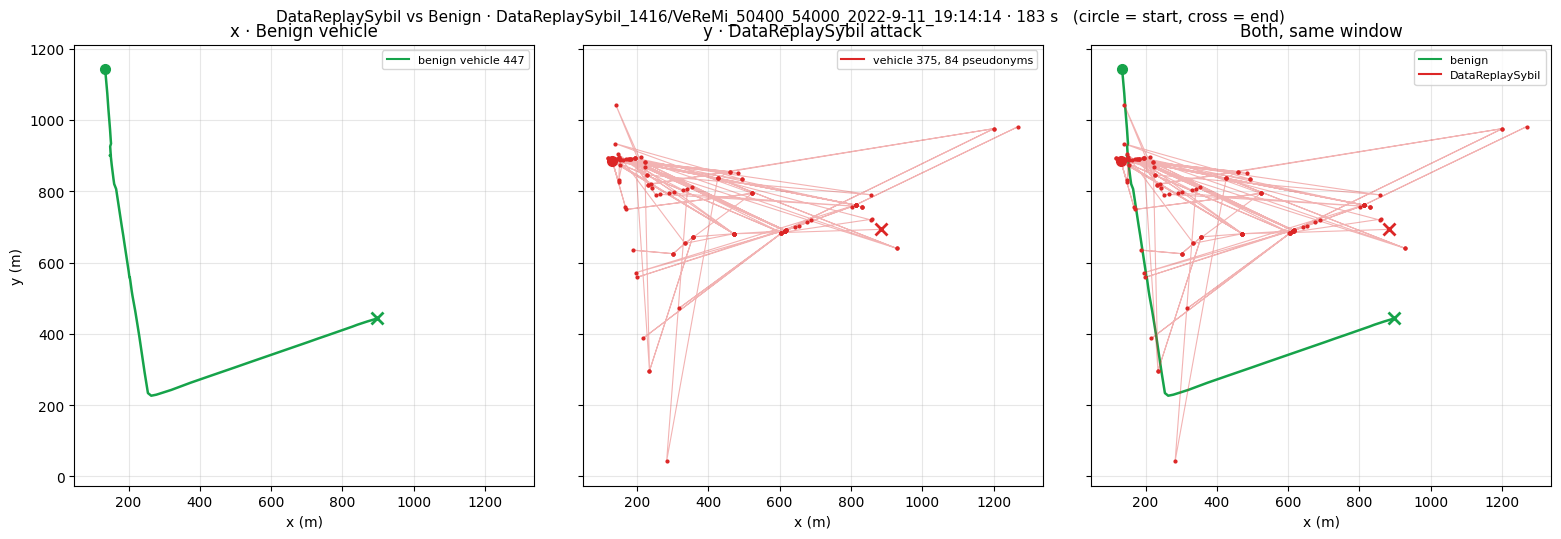

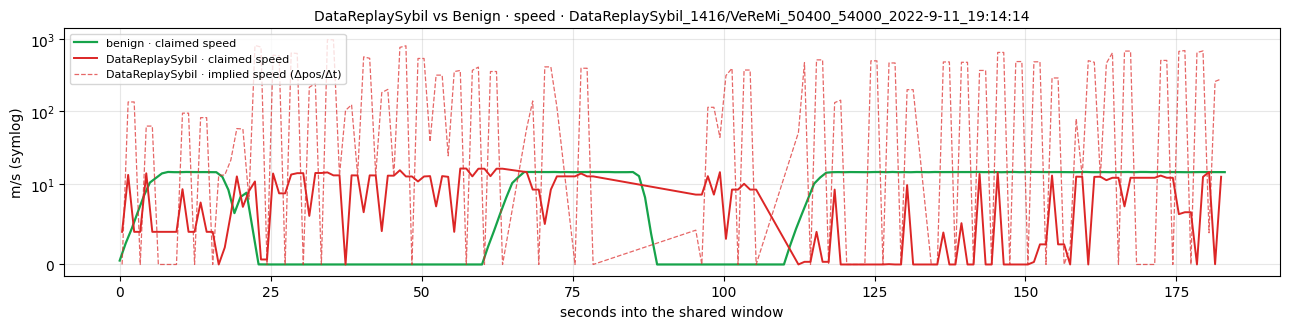

In [7]:
pairs["DataReplaySybil"] = build_pair("DataReplaySybil", subfolder=SUBFOLDERS["DataReplaySybil"])
show(pairs["DataReplaySybil"])


## 5. DoSRandomSybil (A18) vs Benign

*Incoherent position jumps at an elevated message rate.*


DoSRandomSybil: Incoherent position jumps at an elevated message rate.
folder: DoSRandomSybil_1416/VeReMi_50400_54000_2022-9-11_19:14:32
benign vehicle 447 vs attacker 375 (100 pseudonyms), shared window 183 s


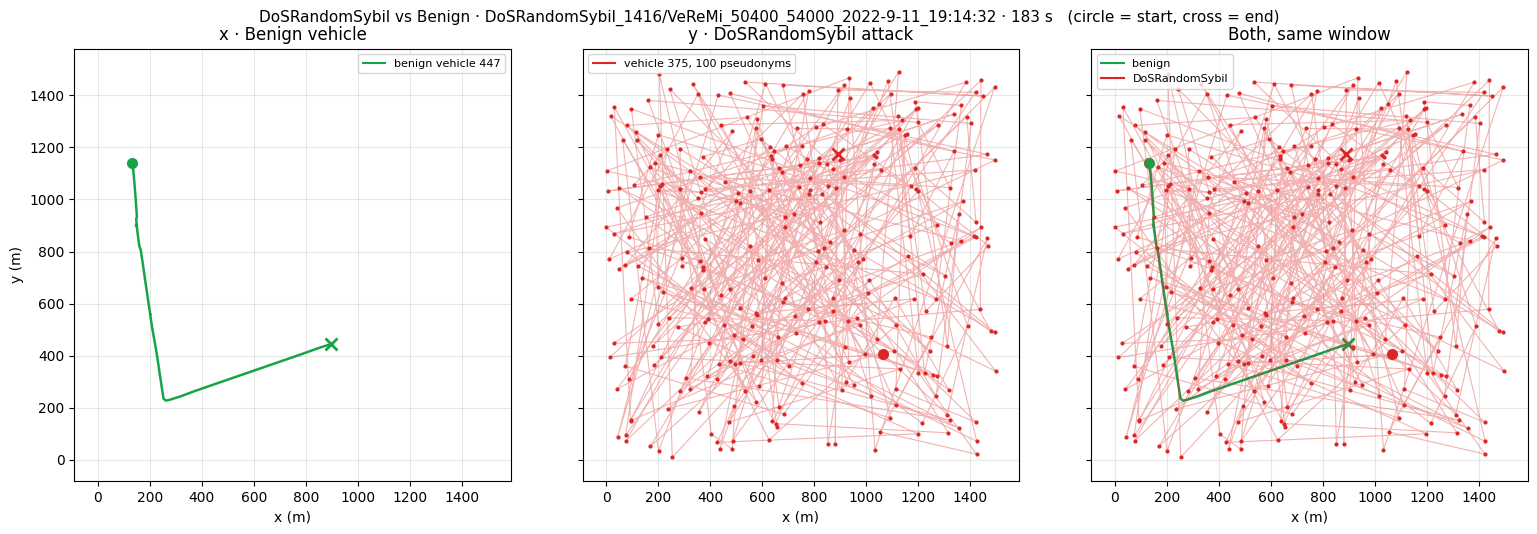

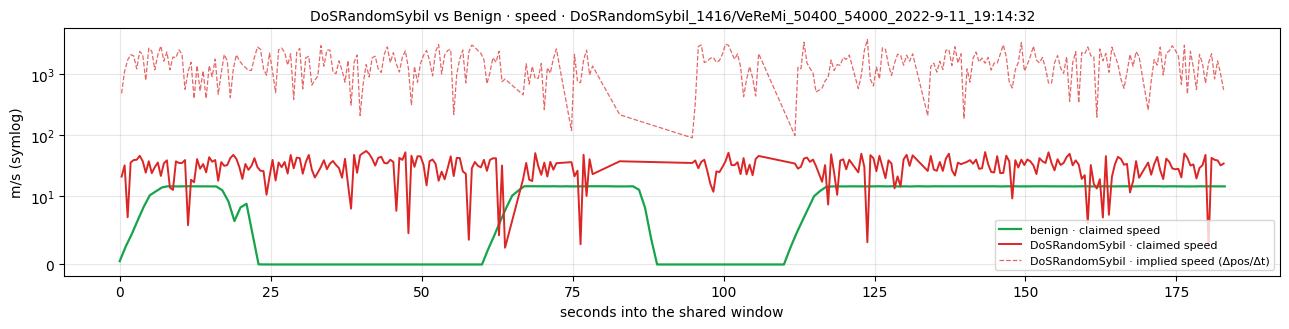

In [8]:
pairs["DoSRandomSybil"] = build_pair("DoSRandomSybil", subfolder=SUBFOLDERS["DoSRandomSybil"])
show(pairs["DoSRandomSybil"])


## 6. DoSDisruptiveSybil (A19) vs Benign

*Mostly single-shot disposable pseudonyms with bursty, irregular timing.*


DoSDisruptiveSybil: Mostly single-shot disposable pseudonyms with bursty, irregular timing.
folder: DoSDisruptiveSybil_1416/VeReMi_50400_54000_2022-9-11_19:14:41
benign vehicle 447 vs attacker 375 (100 pseudonyms), shared window 183 s


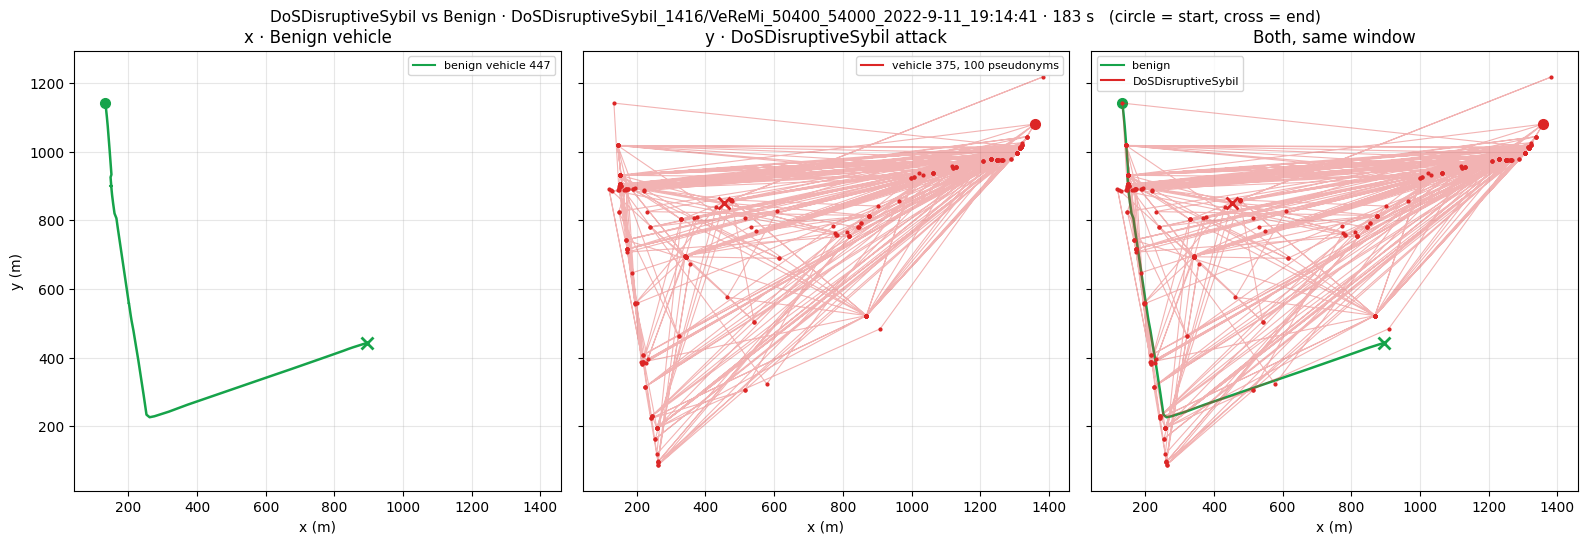

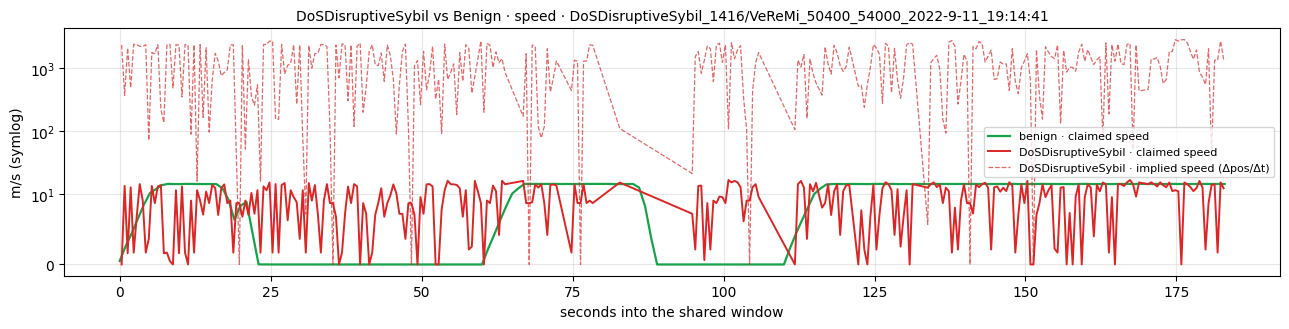

In [9]:
pairs["DoSDisruptiveSybil"] = build_pair("DoSDisruptiveSybil", subfolder=SUBFOLDERS["DoSDisruptiveSybil"])
show(pairs["DoSDisruptiveSybil"])


## 7. All four attack types side by side

`> 60 m/s` is the simulator's teleport threshold; for an honest vehicle almost no step implies that.
`|implied − claimed|` is how far the speed the attacker claims is from the speed its own broadcast
positions imply.

**Worth knowing when reading this table:** with the default 1416 runs, DataReplay, DoSRandom and
DoSDisruptive pick the *same* benign vehicle and the *same* attacker vehicle. Their first 1416 runs appear to
replay one traffic simulation with only the attack changed, so those three rows differ only by attack type:
a controlled comparison. GridSybil's run is a separate simulation.


In [10]:
rows = []
for family in FAMILIES:
    p = pairs.get(family)
    if not p or not p["ok"]:
        rows.append({"attack type": family, "folder": p["folder"] if p else "", "note": p["why"] if p else "not run"})
        continue
    residual = np.abs(p["attack_implied"] - np.hypot(*p["attack_spd"].T))
    rows.append({
        "attack type": family,
        "folder": p["folder"],
        "benign vehicle": p["benign_node"],
        "attacker": p["attack_node"],
        "attack trace": trace_label(p),
        "shared s": round(p["hi"] - p["lo"]),
        "benign steps": len(p["benign_t"]),
        "attack msgs": len(p["attack_t"]),
        "attack steps > 60 m/s": f"{np.nanmean(p['attack_implied'] > 60):.0%}",
        "median |implied - claimed| m/s": round(float(np.nanmedian(residual)), 1),
    })
pd.set_option("display.max_colwidth", 60)
pd.DataFrame(rows)


,attack type,folder,benign vehicle,attacker,attack trace,shared s,benign steps,attack msgs,attack steps > 60 m/s,median |implied - claimed| m/s
0,GridSybil,GridSybil_1416/VeReMi_50400_54000_2022-9-11_19:13:55,117,111,fake pseudonym #201115,182,182,170,4%,5.1
1,DataReplaySybil,DataReplaySybil_1416/VeReMi_50400_54000_2022-9-11_19:14:14,447,375,84 pseudonyms,183,184,152,58%,116.3
2,DoSRandomSybil,DoSRandomSybil_1416/VeReMi_50400_54000_2022-9-11_19:14:32,447,375,100 pseudonyms,183,184,306,100%,1468.3
3,DoSDisruptiveSybil,DoSDisruptiveSybil_1416/VeReMi_50400_54000_2022-9-11_19:...,447,375,100 pseudonyms,183,184,306,94%,1278.8
